# 03. Modeling — 모델 선택부터 외부 Batch 검증까지

**Day 2 Regression · 배터리 Cycle Life 예측**  
작성자: **U094 이수현** · 작성일: **2026-10-02**

> 목표: Batch 1 안에서 Feature와 모델을 선택하고 설정을 동결한 뒤, Batch 2를 최종 외부 테스트로 평가하고 같은 설정으로 Batch 3 일반화를 확인한다.

이 노트북은 모델링의 **주 실행본**이다. Pipeline, 반복 CV, Hyperparameter grid, ΔQ screening, F0~F4 Ablation, 1-SE 선정, hold-out, 외부 예측, 지표·Gap·오류·분포 이동·시각화 코드가 직접 들어 있다.

`RUN_FULL_CV_SEARCH = False`에서는 시간이 오래 걸리는 전체 탐색 결과만 저장본에서 읽는다. 탐색 코드는 그대로 보이며 `True`로 바꾸면 같은 계산을 수행한다. 최종 Ridge 적합과 hold-out·Batch 2·Batch 3 예측은 기본 Run All에서도 실제로 다시 수행한다.

> **편집 주의:** 이 파일을 직접 보완한 뒤 `src/build_day2_notebooks.py`를 다시 실행하면 수동 변경이 덮어써진다. 앞으로 노트북을 주 작업본으로 사용할 때는 먼저 Git commit이나 별도 백업을 남긴다.

## 1. 환경과 입력 데이터

`02_feature_engineering.ipynb`가 만든 Cell당 1행 Feature Table과 고정 split을 읽는다. 모델 입력에 cycle_life, Cell ID, Batch 이름이 들어가지 않는지 다시 검사한다.

In [1]:
from pathlib import Path
from typing import Any, Iterable
import json
import math

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import HTML, display
from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, RepeatedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RESULT_DIR = ROOT / "results" / "day2"
RANDOM_SEED = 20261002
REFERENCE_MAPE = 9.1
FORBIDDEN_FEATURE_PATTERNS = (
    "cycle_life", "knee", "eol", "target", "observed_end",
    "global_cell_id", "cell_index", "batch",
)

font_candidates = [
    Path("/Users/lsh/Library/Fonts/NotoSansKR-Regular.otf"),
    Path("/System/Library/Fonts/AppleSDGothicNeo.ttc"),
    Path("/System/Library/Fonts/Supplemental/AppleGothic.ttf"),
]
font_path = next((path for path in font_candidates if path.exists()), None)
if font_path:
    fm.fontManager.addfont(str(font_path))
    plt.rcParams["font.family"] = fm.FontProperties(fname=str(font_path)).get_name()
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

display(HTML("""
<style>
.jp-Notebook { max-width: 1180px; margin: auto; }
.jp-MarkdownOutput h1 { color:#173B5E; border-bottom:3px solid #1A9AA3; padding-bottom:.35rem; }
.jp-MarkdownOutput h2 { color:#173B5E; margin-top:2rem; }
.jp-MarkdownOutput h3 { color:#138A92; }
.jp-MarkdownOutput blockquote { border-left:5px solid #1A9AA3; background:#F1F8F8; padding:.75rem 1rem; }
.dataframe { font-size:13px; }
</style>
"""))

print("프로젝트 루트:", ROOT)

프로젝트 루트: /Users/lsh/ess-battery-health


In [2]:
feature_table = pd.read_csv(RESULT_DIR / "feature_table.csv")
split_assignment = pd.read_csv(RESULT_DIR / "split_assignment.csv")
data = feature_table.merge(
    split_assignment[["global_cell_id", "split"]],
    on="global_cell_id", how="left", validate="one_to_one"
)
development = data.query("split == 'development'").reset_index(drop=True)
holdout = data.query("split == 'holdout'").reset_index(drop=True)
batch2 = data.query("split == 'external_test'").reset_index(drop=True)
batch3 = data.query("split == 'additional_test'").reset_index(drop=True)
display(pd.DataFrame({
    "구간": ["Batch 1 development", "Batch 1 hold-out", "Batch 2 test", "Batch 3 additional"],
    "Cell 수": [len(development), len(holdout), len(batch2), len(batch3)],
    "평균 수명": [development.cycle_life.mean(), holdout.cycle_life.mean(), batch2.cycle_life.mean(), batch3.cycle_life.mean()],
}).round(1))
assert (len(development), len(holdout), len(batch2), len(batch3)) == (36, 10, 39, 44)

,구간,Cell 수,평균 수명
0,Batch 1 development,36,857.6000
1,Batch 1 hold-out,10,798.4000
2,Batch 2 test,39,565.7000
3,Batch 3 additional,44,"1,059.7000"


## 2. CV·Pipeline·모델 후보의 실제 구현

모든 전처리는 Pipeline 안에 둔다. `SimpleImputer`와 `StandardScaler`는 각 CV train fold에서만 fit되므로 validation 통계가 학습에 새지 않는다.

모델 후보는 Median Baseline, Linear Regression, Ridge, ElasticNet, 제한된 Gradient Boosting이다. 작은 정형 데이터이므로 딥러닝은 표본 대비 복잡성과 설명 부담이 커서 제외했다.

In [3]:
def numeric_frame(frame: pd.DataFrame, features: list[str]) -> pd.DataFrame:
    result = frame[features].copy()
    for column in result:
        result[column] = pd.to_numeric(result[column], errors="coerce")
    return result

def make_cv_splits(n_samples: int) -> list[tuple[np.ndarray, np.ndarray]]:
    cv = RepeatedKFold(n_splits=5, n_repeats=10, random_state=RANDOM_SEED)
    dummy = np.zeros((n_samples, 1))
    return list(cv.split(dummy))

def make_model_specs() -> dict[str, tuple[Pipeline, dict[str, list[Any]], int]]:
    linear_pre = [
        ("imputer", SimpleImputer(strategy="median", add_indicator=True, keep_empty_features=True)),
        ("scaler", StandardScaler()),
    ]
    tree_pre = [
        ("imputer", SimpleImputer(strategy="median", add_indicator=True, keep_empty_features=True)),
    ]
    return {
        "Median Baseline": (
            Pipeline([("imputer", SimpleImputer(strategy="median", keep_empty_features=True)), ("model", DummyRegressor(strategy="median"))]),
            {},
            0,
        ),
        "Linear Regression": (
            Pipeline(linear_pre + [("model", LinearRegression())]),
            {},
            1,
        ),
        "Ridge": (
            Pipeline(linear_pre + [("model", Ridge())]),
            {"model__alpha": list(np.logspace(-4, 4, 9))},
            2,
        ),
        "ElasticNet": (
            Pipeline(linear_pre + [("model", ElasticNet(max_iter=100000, random_state=RANDOM_SEED))]),
            {
                "model__alpha": list(np.logspace(-4, 1, 6)),
                "model__l1_ratio": [0.1, 0.5, 0.9],
            },
            3,
        ),
        "Gradient Boosting": (
            Pipeline(tree_pre + [("model", GradientBoostingRegressor(random_state=RANDOM_SEED))]),
            {
                "model__n_estimators": [50, 100, 200],
                "model__learning_rate": [0.02, 0.05, 0.10],
                "model__max_depth": [1, 2],
                "model__min_samples_leaf": [3, 5, 8],
                "model__subsample": [0.7, 1.0],
            },
            4,
        ),
    }

def tune_and_score(
    X: pd.DataFrame,
    y: pd.Series,
    pipeline: Pipeline,
    grid: dict[str, list[Any]],
    cv_splits: list[tuple[np.ndarray, np.ndarray]],
) -> tuple[Pipeline, dict[str, Any], pd.DataFrame, dict[str, float]]:
    search = GridSearchCV(
        estimator=pipeline,
        param_grid=grid if grid else [{}],
        scoring=SCORING,
        refit="mape",
        cv=cv_splits,
        n_jobs=-1,
        return_train_score=False,
        error_score="raise",
    )
    search.fit(X, y)
    best = clone(search.best_estimator_)
    cv_result = cross_validate(
        best,
        X,
        y,
        scoring=SCORING,
        cv=cv_splits,
        n_jobs=-1,
        error_score="raise",
    )
    fold = pd.DataFrame(
        {
            "fold": np.arange(1, len(cv_splits) + 1),
            "repeat": np.repeat(np.arange(1, 11), 5),
            "fold_in_repeat": np.tile(np.arange(1, 6), 10),
            "mape_pct": -100 * cv_result["test_mape"],
            "mae": -cv_result["test_mae"],
            "rmse": -cv_result["test_rmse"],
            "r2": cv_result["test_r2"],
        }
    )
    repeat_means = fold.groupby("repeat")["mape_pct"].mean()
    summary = {
        "cv_mape_mean": float(fold["mape_pct"].mean()),
        "cv_mape_std": float(fold["mape_pct"].std(ddof=1)),
        "cv_mape_se": float(repeat_means.std(ddof=1) / math.sqrt(len(repeat_means))),
        "cv_mae_mean": float(fold["mae"].mean()),
        "cv_rmse_mean": float(fold["rmse"].mean()),
        "cv_r2_mean": float(fold["r2"].mean()),
    }
    return best, search.best_params_, fold, summary

In [4]:
SCORING = {
    "mape": "neg_mean_absolute_percentage_error",
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2",
}
cv_splits = make_cv_splits(len(development))
model_specs = make_model_specs()
print(f"동일하게 재사용할 CV 분할 수: {len(cv_splits)} = 5 folds × 10 repeats")
for name, (pipeline, grid, complexity) in model_specs.items():
    combinations = int(np.prod([len(values) for values in grid.values()])) if grid else 1
    print(f"\n[{name}] 복잡도 순위={complexity} · 탐색 조합={combinations}")
    print(pipeline)

동일하게 재사용할 CV 분할 수: 50 = 5 folds × 10 repeats

[Median Baseline] 복잡도 순위=0 · 탐색 조합=1
Pipeline(steps=[('imputer',
                 SimpleImputer(keep_empty_features=True, strategy='median')),
                ('model', DummyRegressor(strategy='median'))])

[Linear Regression] 복잡도 순위=1 · 탐색 조합=1
Pipeline(steps=[('imputer',
                 SimpleImputer(add_indicator=True, keep_empty_features=True,
                               strategy='median')),
                ('scaler', StandardScaler()), ('model', LinearRegression())])

[Ridge] 복잡도 순위=2 · 탐색 조합=9
Pipeline(steps=[('imputer',
                 SimpleImputer(add_indicator=True, keep_empty_features=True,
                               strategy='median')),
                ('scaler', StandardScaler()), ('model', Ridge())])

[ElasticNet] 복잡도 순위=3 · 탐색 조합=18
Pipeline(steps=[('imputer',
                 SimpleImputer(add_indicator=True, keep_empty_features=True,
                               strategy='median')),
                ('scaler', Sta

`GridSearchCV`와 최종 `cross_validate` 모두 같은 50개 fold를 사용한다. 평균 MAPE뿐 아니라 표준편차, repeat 간 표준오차, MAE, RMSE, R²를 함께 저장한다.

## 3. ΔQ 대표 Feature screening

같은 곡선에서 만든 네 후보를 동시에 넣지 않는다. Batch 1 development만 사용하고 동일한 Ridge·동일한 split에서 하나씩 비교한다.

In [5]:
RUN_FULL_CV_SEARCH = False
dq_candidates = ["delta_q_log10_var", "delta_q_iqr", "delta_q_min", "delta_q_abs_area"]

if RUN_FULL_CV_SEARCH:
    dq_rows, dq_fold_frames = [], []
    ridge_pipe, ridge_grid, _ = model_specs["Ridge"]
    for candidate in dq_candidates:
        _, params, fold, summary = tune_and_score(
            numeric_frame(development, [candidate]), development["cycle_life"],
            ridge_pipe, ridge_grid, cv_splits,
        )
        dq_rows.append({"feature": candidate, **summary, "best_params": json.dumps(params, ensure_ascii=False)})
        fold["feature"] = candidate
        dq_fold_frames.append(fold)
    dq_results = pd.DataFrame(dq_rows).sort_values("cv_mape_mean").reset_index(drop=True)
    dq_folds = pd.concat(dq_fold_frames, ignore_index=True)
else:
    dq_results = pd.read_csv(RESULT_DIR / "delta_q_candidate_results.csv")
    dq_folds = pd.read_csv(RESULT_DIR / "delta_q_candidate_folds.csv")

best_dq = dq_results.sort_values("cv_mape_mean").iloc[0]
predeclared = dq_results.query("feature == 'delta_q_log10_var'").iloc[0]
chosen_dq = (
    "delta_q_log10_var"
    if predeclared["cv_mape_mean"] <= best_dq["cv_mape_mean"] + best_dq["cv_mape_se"]
    else str(best_dq["feature"])
)
dq_results["selected_core_recomputed"] = dq_results["feature"].eq(chosen_dq)
display(dq_results[["feature", "cv_mape_mean", "cv_mape_std", "cv_mape_se", "selected_core_recomputed"]].round(3))
print("선정된 ΔQ Core:", chosen_dq)

,feature,cv_mape_mean,cv_mape_std,cv_mape_se,selected_core_recomputed
0,delta_q_iqr,8.2630,2.4130,0.0510,True
1,delta_q_log10_var,9.0050,2.0660,0.0990,False
2,delta_q_min,9.0550,2.6850,0.0710,False
3,delta_q_abs_area,10.3380,3.0920,0.1090,False


선정된 ΔQ Core: delta_q_iqr


사전 1순위 `delta_q_log10_var`가 최저 후보의 1-SE 안에 들어오면 계획을 유지하고, 그렇지 않을 때만 최저 후보로 바꾼다. 실제로는 IQR 8.26%, log-variance 9.00%였고 1-SE 밖이어서 IQR을 선택했다. Batch 2를 보기 전의 결정이다.

## 4. F0~F4 Feature Ablation과 다섯 모델 전체 비교

아래 딕셔너리가 Feature 선정 논리를 코드로 명시한다. 이후 모든 조합은 같은 `cv_splits`를 사용한다.

In [6]:
feature_sets = {
    "F0 Capacity": ["qd_mean", "qd_slope"],
    "F1 ΔQ": [chosen_dq],
    "F2 ΔQ+Capacity": [chosen_dq, "qd_mean", "qd_slope"],
    "F3 +Sensor": [chosen_dq, "qd_mean", "qd_slope", "ir_mean", "tavg_mean", "chargetime_mean"],
    "F4 +Charging": [
        chosen_dq, "qd_mean", "qd_slope", "ir_mean", "tavg_mean", "chargetime_mean",
        "c_rate_stage1", "switch_soc_pct", "c_rate_stage2", "policy_new_structure", "policy_slow_cycle",
    ],
}
for set_name, columns in feature_sets.items():
    leaked = [name for name in columns if any(token in name.lower() for token in FORBIDDEN_FEATURE_PATTERNS)]
    if leaked:
        raise AssertionError(f"{set_name}에 미래정보·식별자 포함: {leaked}")
    print(f"{set_name:18s} · {len(columns):2d}개 · {columns}")

F0 Capacity        ·  2개 · ['qd_mean', 'qd_slope']
F1 ΔQ              ·  1개 · ['delta_q_iqr']
F2 ΔQ+Capacity     ·  3개 · ['delta_q_iqr', 'qd_mean', 'qd_slope']
F3 +Sensor         ·  6개 · ['delta_q_iqr', 'qd_mean', 'qd_slope', 'ir_mean', 'tavg_mean', 'chargetime_mean']
F4 +Charging       · 11개 · ['delta_q_iqr', 'qd_mean', 'qd_slope', 'ir_mean', 'tavg_mean', 'chargetime_mean', 'c_rate_stage1', 'switch_soc_pct', 'c_rate_stage2', 'policy_new_structure', 'policy_slow_cycle']


In [7]:
if RUN_FULL_CV_SEARCH:
    comparison_rows, all_fold_frames = [], []
    for set_name, columns in feature_sets.items():
        X_dev, y_dev = numeric_frame(development, columns), development["cycle_life"]
        for model_name, (pipeline, grid, complexity) in model_specs.items():
            print(f"실행: {set_name} / {model_name}")
            _, params, fold, summary = tune_and_score(X_dev, y_dev, pipeline, grid, cv_splits)
            comparison_rows.append({
                "feature_set": set_name, "model": model_name,
                "feature_count": len(columns), "model_complexity_rank": complexity,
                **summary, "best_params": json.dumps(params, ensure_ascii=False, sort_keys=True),
                "features": ", ".join(columns),
            })
            fold["feature_set"], fold["model"] = set_name, model_name
            all_fold_frames.append(fold)
    comparison = pd.DataFrame(comparison_rows).sort_values("cv_mape_mean").reset_index(drop=True)
    fold_results = pd.concat(all_fold_frames, ignore_index=True)
else:
    comparison = pd.read_csv(RESULT_DIR / "model_comparison.csv")
    fold_results = pd.read_csv(RESULT_DIR / "cv_fold_results.csv")

best_mean = float(comparison.iloc[0]["cv_mape_mean"])
one_se_threshold = best_mean + float(comparison.iloc[0]["cv_mape_se"])
comparison["within_one_se_recomputed"] = comparison["cv_mape_mean"] <= one_se_threshold
display(comparison.head(12)[[
    "feature_set", "model", "feature_count", "cv_mape_mean", "cv_mape_std",
    "cv_mae_mean", "cv_rmse_mean", "cv_r2_mean", "best_params", "within_one_se_recomputed"
]].round(3))

,feature_set,model,feature_count,cv_mape_mean,cv_mape_std,cv_mae_mean,cv_rmse_mean,cv_r2_mean,best_params,within_one_se_recomputed
0,F4 +Charging,ElasticNet,11,7.5630,2.0200,63.8990,76.3100,0.7710,"{""model__alpha"": 1.0, ""model__l1_ratio"": 0.9}",True
1,F2 ΔQ+Capacity,Ridge,3,7.6760,2.1780,64.2400,78.9910,0.7400,"{""model__alpha"": 1.0}",True
2,F2 ΔQ+Capacity,ElasticNet,3,7.6810,2.1470,64.4280,79.2720,0.7400,"{""model__alpha"": 0.1, ""model__l1_ratio"": 0.5}",True
3,F2 ΔQ+Capacity,Linear Regression,3,7.7440,2.2740,64.5410,78.8780,0.7370,{},False
4,F3 +Sensor,ElasticNet,6,7.7490,1.7690,64.5060,74.4790,0.7830,"{""model__alpha"": 1.0, ""model__l1_ratio"": 0.9}",False
5,F4 +Charging,Ridge,11,7.8700,2.3010,66.1960,80.0340,0.7430,"{""model__alpha"": 10.0}",False
6,F3 +Sensor,Ridge,6,7.9150,2.1470,65.8240,76.3620,0.7680,"{""model__alpha"": 1.0}",False
7,F4 +Charging,Gradient Boosting,11,8.0110,2.7350,65.4780,82.2330,0.7230,"{""model__learning_rate"": 0.05, ""model__max_depth"": 2, ""model__min_samples_leaf"": 3, ""model__n_es...",False
8,F3 +Sensor,Linear Regression,6,8.0910,2.4560,67.2860,78.6180,0.7520,{},False
9,F2 ΔQ+Capacity,Gradient Boosting,3,8.1640,2.7090,67.3610,87.0230,0.6550,"{""model__learning_rate"": 0.1, ""model__max_depth"": 1, ""model__min_samples_leaf"": 3, ""model__n_est...",False


/var/folders/zb/jr1wvwf97ssf0lbcg9tv2fhr0000gn/T/ipykernel_17523/3765759192.py:14: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/zb/jr1wvwf97ssf0lbcg9tv2fhr0000gn/T/ipykernel_17523/3765759192.py:14: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/zb/jr1wvwf97ssf0lbcg9tv2fhr0000gn/T/ipykernel_17523/3765759192.py:14: UserWarning: Glyph 44057 (\N{HANGUL SYLLABLE GAT}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/zb/jr1wvwf97ssf0lbcg9tv2fhr0000gn/T/ipykernel_17523/3765759192.py:14: UserWarning: Glyph 51008 (\N{HANGUL SYLLABLE EUN}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/zb/jr1wvwf97ssf0lbcg9tv2fhr0000gn/T/ipykernel_17523/3765759192.py:14: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/zb/jr1wvwf97s

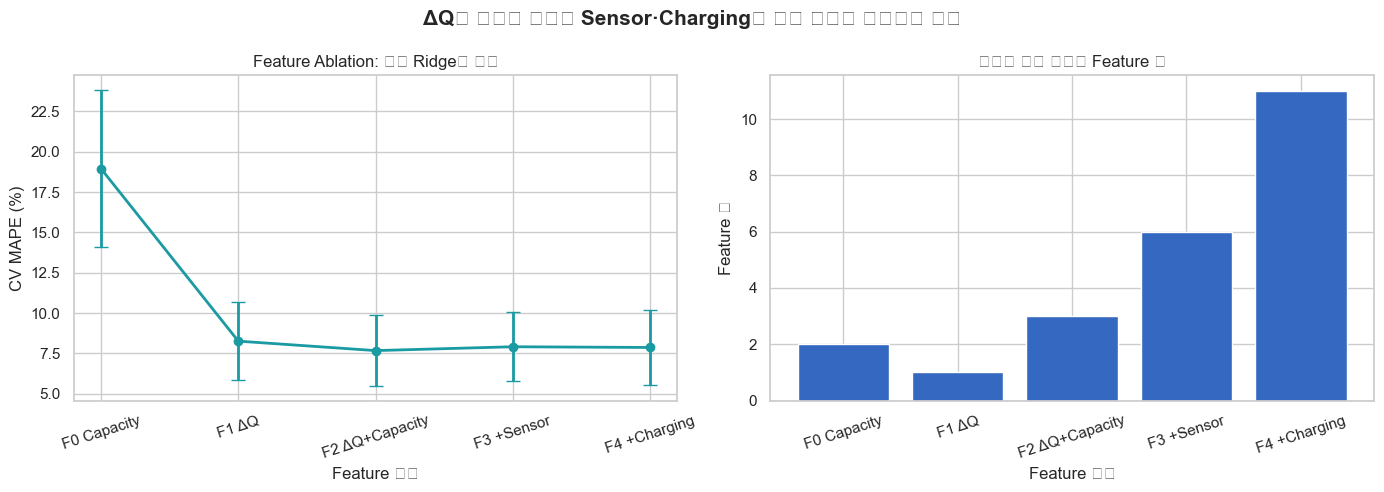

,feature_set,feature_count,cv_mape_mean,cv_mape_std,features
22,F0 Capacity,2,18.9470,4.8690,"qd_mean, qd_slope"
12,F1 ΔQ,1,8.2630,2.4130,delta_q_iqr
1,F2 ΔQ+Capacity,3,7.6760,2.1780,"delta_q_iqr, qd_mean, qd_slope"
6,F3 +Sensor,6,7.9150,2.1470,"delta_q_iqr, qd_mean, qd_slope, ir_mean, tavg_mean, chargetime_mean"
5,F4 +Charging,11,7.8700,2.3010,"delta_q_iqr, qd_mean, qd_slope, ir_mean, tavg_mean, chargetime_mean, c_rate_stage1, switch_soc_p..."


In [8]:
stage_order = ["F0 Capacity", "F1 ΔQ", "F2 ΔQ+Capacity", "F3 +Sensor", "F4 +Charging"]
ablation = comparison.query("model == 'Ridge'").copy()
ablation["feature_set"] = pd.Categorical(ablation["feature_set"], stage_order, ordered=True)
ablation = ablation.sort_values("feature_set")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].errorbar(ablation["feature_set"].astype(str), ablation["cv_mape_mean"],
                 yerr=ablation["cv_mape_std"], fmt="o-", capsize=5, color="#1A9AA3", lw=2)
axes[0].set(title="Feature Ablation: 같은 Ridge로 비교", xlabel="Feature 단계", ylabel="CV MAPE (%)")
axes[0].tick_params(axis="x", rotation=18)
axes[1].bar(ablation["feature_set"].astype(str), ablation["feature_count"], color="#3568C0")
axes[1].set(title="성능과 함께 증가한 Feature 수", xlabel="Feature 단계", ylabel="Feature 수")
axes[1].tick_params(axis="x", rotation=18)
fig.suptitle("ΔQ의 기여는 크지만 Sensor·Charging의 추가 이득은 확인되지 않음", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.show()
display(ablation[["feature_set", "feature_count", "cv_mape_mean", "cv_mape_std", "features"]].round(3))

Capacity만 사용한 F0 18.95%에서 ΔQ만 사용한 F1 8.26%로 크게 개선되고, Capacity를 결합한 F2가 7.68%로 추가 개선된다. Sensor와 Charging을 더한 F3·F4는 변수 수가 늘지만 Ridge MAPE가 악화된다.

## 5. 1-SE 규칙으로 최종 후보 선정

최저 평균 MAPE와 구분하기 어려운 후보를 남긴 뒤 Feature 수 → 모델 복잡도 → 평균 MAPE 순으로 정렬한다. 작은 표본에서 미세한 점수 차이보다 단순성과 안정성을 우선한다.

In [9]:
eligible = comparison[comparison["within_one_se_recomputed"]].sort_values(
    ["feature_count", "model_complexity_rank", "cv_mape_mean"]
)
selected_row = eligible.iloc[0]
selected_feature_set = str(selected_row["feature_set"])
selected_model_name = str(selected_row["model"])
selected_features = feature_sets[selected_feature_set]
selected_params = json.loads(selected_row["best_params"])
display(eligible[["feature_set", "model", "feature_count", "model_complexity_rank", "cv_mape_mean", "cv_mape_std", "best_params"]].round(3))
print("최종 선택:", selected_feature_set, "+", selected_model_name)
print("Feature:", selected_features)
print("설정:", selected_params)
assert selected_feature_set == "F2 ΔQ+Capacity"
assert selected_model_name == "Ridge"
assert selected_params == {"model__alpha": 1.0}

,feature_set,model,feature_count,model_complexity_rank,cv_mape_mean,cv_mape_std,best_params
1,F2 ΔQ+Capacity,Ridge,3,2,7.6760,2.1780,"{""model__alpha"": 1.0}"
2,F2 ΔQ+Capacity,ElasticNet,3,3,7.6810,2.1470,"{""model__alpha"": 0.1, ""model__l1_ratio"": 0.5}"
0,F4 +Charging,ElasticNet,11,3,7.5630,2.0200,"{""model__alpha"": 1.0, ""model__l1_ratio"": 0.9}"


최종 선택: F2 ΔQ+Capacity + Ridge
Feature: ['delta_q_iqr', 'qd_mean', 'qd_slope']
설정: {'model__alpha': 1.0}


/var/folders/zb/jr1wvwf97ssf0lbcg9tv2fhr0000gn/T/ipykernel_17523/2998302404.py:9: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) Arial.
  ax.legend(); plt.tight_layout(); plt.show()
/var/folders/zb/jr1wvwf97ssf0lbcg9tv2fhr0000gn/T/ipykernel_17523/2998302404.py:9: UserWarning: Glyph 48373 (\N{HANGUL SYLLABLE BOG}) missing from font(s) Arial.
  ax.legend(); plt.tight_layout(); plt.show()
/var/folders/zb/jr1wvwf97ssf0lbcg9tv2fhr0000gn/T/ipykernel_17523/2998302404.py:9: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) Arial.
  ax.legend(); plt.tight_layout(); plt.show()
/var/folders/zb/jr1wvwf97ssf0lbcg9tv2fhr0000gn/T/ipykernel_17523/2998302404.py:9: UserWarning: Glyph 45944 (\N{HANGUL SYLLABLE DEL}) missing from font(s) Arial.
  ax.legend(); plt.tight_layout(); plt.show()
/var/folders/zb/jr1wvwf97ssf0lbcg9tv2fhr0000gn/T/ipykernel_17523/2998302404.py:9: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) Arial.
  ax.legend()

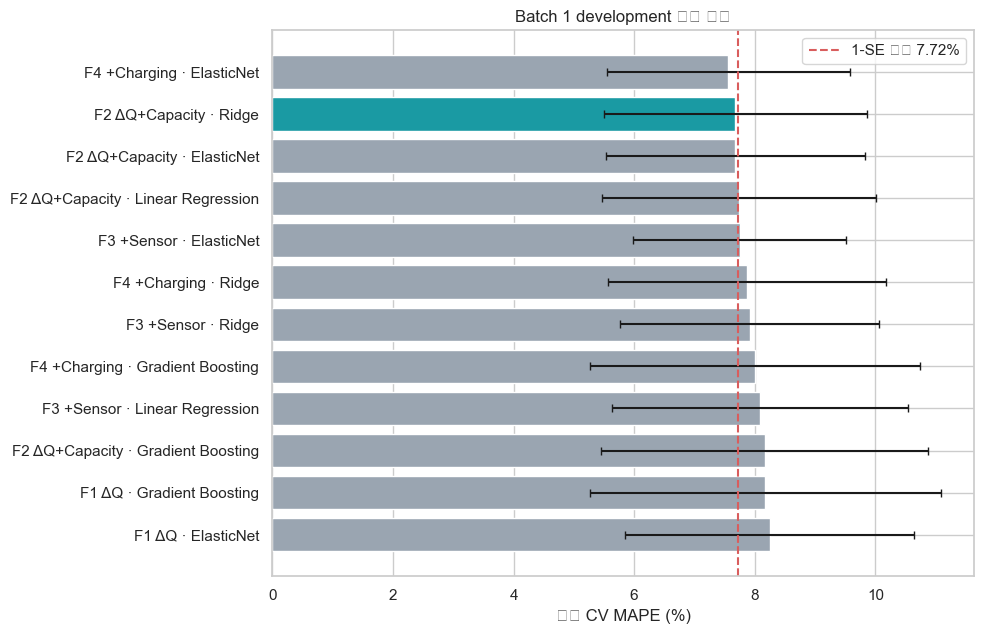

In [10]:
top = comparison.head(12).sort_values("cv_mape_mean", ascending=False).copy()
top["후보"] = top["feature_set"] + " · " + top["model"]
colors_top = ["#1A9AA3" if (fs == selected_feature_set and model == selected_model_name) else "#9AA5B1"
              for fs, model in zip(top["feature_set"], top["model"])]
fig, ax = plt.subplots(figsize=(10, 6.5))
ax.barh(top["후보"], top["cv_mape_mean"], xerr=top["cv_mape_std"], color=colors_top, capsize=3)
ax.axvline(one_se_threshold, color="#D95D5D", ls="--", label=f"1-SE 경계 {one_se_threshold:.2f}%")
ax.set(title="Batch 1 development 모델 비교", xlabel="반복 CV MAPE (%)", ylabel="")
ax.legend(); plt.tight_layout(); plt.show()

## 6. Batch 1 fixed hold-out — 설정 동결 전 최종 점검

선택된 Pipeline을 새로 만들고 development 36개에만 fit한다. 아래 예측은 저장값이 아니라 노트북에서 실제로 다시 계산된다.

In [11]:
def life_group(value: float) -> str:
    if not np.isfinite(value):
        return "Target 결측"
    if value < 500:
        return "단수명(<500)"
    if value > 1000:
        return "장수명(>1,000)"
    return "중간수명(500~1,000)"

def regression_metrics(y_true: Iterable[float], y_pred: Iterable[float]) -> dict[str, float]:
    y_true_array = np.asarray(list(y_true), dtype=float)
    y_pred_array = np.asarray(list(y_pred), dtype=float)
    return {
        "mape_pct": float(100 * mean_absolute_percentage_error(y_true_array, y_pred_array)),
        "mae": float(mean_absolute_error(y_true_array, y_pred_array)),
        "rmse": float(np.sqrt(mean_squared_error(y_true_array, y_pred_array))),
        "r2": float(r2_score(y_true_array, y_pred_array)) if len(y_true_array) >= 2 else np.nan,
        "median_ape_pct": float(np.median(np.abs(y_true_array - y_pred_array) / np.abs(y_true_array)) * 100),
    }

def bootstrap_mape_ci(y_true: np.ndarray, y_pred: np.ndarray, n_boot: int = 5000) -> tuple[float, float]:
    rng = np.random.default_rng(RANDOM_SEED)
    n = len(y_true)
    values = np.empty(n_boot)
    for idx in range(n_boot):
        sample = rng.integers(0, n, size=n)
        values[idx] = 100 * mean_absolute_percentage_error(y_true[sample], y_pred[sample])
    return float(np.quantile(values, 0.025)), float(np.quantile(values, 0.975))

In [12]:
base_pipeline, _, _ = model_specs[selected_model_name]
selected_estimator = clone(base_pipeline).set_params(**selected_params)
selected_estimator.fit(numeric_frame(development, selected_features), development["cycle_life"])
holdout_prediction = selected_estimator.predict(numeric_frame(holdout, selected_features))
holdout_metrics = regression_metrics(holdout["cycle_life"], holdout_prediction)
selected_cv_row = comparison.query("feature_set == @selected_feature_set and model == @selected_model_name").iloc[0]
stability_limit = selected_cv_row["cv_mape_mean"] + 2 * selected_cv_row["cv_mape_std"]
display(pd.Series({**holdout_metrics, "사전 안정성 상한": stability_limit,
                   "통과": holdout_metrics["mape_pct"] <= stability_limit}).to_frame("값"))
assert holdout_metrics["mape_pct"] <= stability_limit
saved_holdout = pd.read_csv(RESULT_DIR / "predictions.csv").query("dataset == 'Batch 1 Hold-out'")
saved_holdout = saved_holdout.set_index("global_cell_id").loc[holdout["global_cell_id"]]
print("저장 예측과 최대 절대차:", np.max(np.abs(holdout_prediction - saved_holdout["prediction"].to_numpy())))

,값
mape_pct,4.9898
mae,41.9291
rmse,58.3849
r2,0.8530
median_ape_pct,3.6577
사전 안정성 상한,12.0324
통과,True


저장 예측과 최대 절대차: 1.3642420526593924e-12


Hold-out MAPE는 4.99%로 안정성 상한을 통과했다. 이 시점에서 Feature, 전처리, 모델, alpha를 동결한다. 이후 Batch 2 결과를 보고 어떤 설정도 바꾸지 않는다.

## 7. 설정 잠금 확인 후 Batch 2·3 외부 평가

Lock을 검사한 뒤 Batch 1 labeled 46개 전체로 같은 Pipeline을 다시 fit하고 Batch 2·3를 실제로 예측한다.

In [13]:
with open(RESULT_DIR / "external_evaluation_lock.json", encoding="utf-8") as handle:
    lock = json.load(handle)
assert lock["batch2_used_for_selection"] is False
assert lock["post_batch2_retuning"] is False
assert lock["selected_feature_set"] == selected_feature_set
assert lock["selected_model"] == selected_model_name
assert set(lock["selected_features"]) == set(selected_features)
print("외부 평가 잠금 확인:", lock["status"])

final_model = clone(base_pipeline).set_params(**selected_params)
batch1_all = data.query("split in ['development', 'holdout']").reset_index(drop=True)
final_model.fit(numeric_frame(batch1_all, selected_features), batch1_all["cycle_life"])
evaluation_sets = [
    ("Batch 1 Hold-out", holdout, holdout_prediction),
    ("Batch 2 Test", batch2, final_model.predict(numeric_frame(batch2, selected_features))),
    ("Batch 3 Test", batch3, final_model.predict(numeric_frame(batch3, selected_features))),
]
prediction_rows = []
for dataset_name, frame, predicted in evaluation_sets:
    for (_, row), y_hat in zip(frame.iterrows(), predicted):
        actual, y_hat = float(row["cycle_life"]), float(y_hat)
        prediction_rows.append({
            "dataset": dataset_name, "batch": row["batch"], "global_cell_id": row["global_cell_id"],
            "cycle_life": actual, "prediction": y_hat, "residual": y_hat - actual,
            "absolute_error": abs(y_hat - actual), "ape_pct": abs(y_hat - actual) / actual * 100,
            "error_direction": "과대 예측" if y_hat > actual else "과소 예측",
            "life_group": life_group(actual), "charging_policy": row["charging_policy"],
            "c_rate_stage1": row["c_rate_stage1"], "switch_soc_pct": row["switch_soc_pct"],
            **{feature: row[feature] for feature in selected_features},
        })
predictions = pd.DataFrame(prediction_rows)
saved_predictions = pd.read_csv(RESULT_DIR / "predictions.csv")
check = predictions[["dataset", "global_cell_id", "prediction"]].merge(
    saved_predictions[["dataset", "global_cell_id", "prediction"]],
    on=["dataset", "global_cell_id"], suffixes=("_재계산", "_저장")
)
print("동결 외부예측 재현 최대 절대차:", np.max(np.abs(check["prediction_재계산"] - check["prediction_저장"])))

외부 평가 잠금 확인: FROZEN_AND_EVALUATED
동결 외부예측 재현 최대 절대차: 3.183231456205249e-12


## 8. MAPE·MAE·RMSE·R²와 모든 Gap 계산

In [14]:
performance_rows = [{
    "dataset": "Train (Batch 1 CV)", "n": len(development),
    "mape_pct": selected_cv_row["cv_mape_mean"], "mape_std_pct": selected_cv_row["cv_mape_std"],
    "mape_ci95_low": np.nan, "mape_ci95_high": np.nan,
    "mae": selected_cv_row["cv_mae_mean"], "rmse": selected_cv_row["cv_rmse_mean"],
    "r2": selected_cv_row["cv_r2_mean"], "median_ape_pct": np.nan,
}]
for dataset_name, frame in predictions.groupby("dataset", sort=False):
    metrics = regression_metrics(frame["cycle_life"], frame["prediction"])
    ci_low, ci_high = bootstrap_mape_ci(frame["cycle_life"].to_numpy(), frame["prediction"].to_numpy())
    performance_rows.append({"dataset": dataset_name, "n": len(frame), "mape_std_pct": np.nan,
                             "mape_ci95_low": ci_low, "mape_ci95_high": ci_high, **metrics})
performance = pd.DataFrame(performance_rows)
metric_lookup = performance.set_index("dataset")["mape_pct"]
gaps = pd.DataFrame([
    {"gap": "Train-Valid", "value_pct_point": metric_lookup["Batch 1 Hold-out"] - metric_lookup["Train (Batch 1 CV)"]},
    {"gap": "Valid-Test", "value_pct_point": metric_lookup["Batch 2 Test"] - metric_lookup["Batch 1 Hold-out"]},
    {"gap": "Target-Test", "value_pct_point": metric_lookup["Batch 2 Test"] - REFERENCE_MAPE},
    {"gap": "Batch2-Batch3", "value_pct_point": metric_lookup["Batch 3 Test"] - metric_lookup["Batch 2 Test"]},
])
display(performance.round(3)); display(gaps.round(3))

,dataset,n,mape_pct,mape_std_pct,mape_ci95_low,mape_ci95_high,mae,rmse,r2,median_ape_pct
0,Train (Batch 1 CV),36,7.6760,2.1780,NaN,NaN,64.2400,78.9910,0.7400,NaN
1,Batch 1 Hold-out,10,4.9900,NaN,2.5010,7.6670,41.9290,58.3850,0.8530,3.6580
2,Batch 2 Test,39,36.5600,NaN,30.5070,43.0060,188.8570,210.9310,0.0750,37.0880
3,Batch 3 Test,44,12.6260,NaN,9.4680,16.2220,162.7560,265.1700,0.2700,10.3050


,gap,value_pct_point
0,Train-Valid,-2.6870
1,Valid-Test,31.5700
2,Target-Test,27.4600
3,Batch2-Batch3,-23.9350


Batch 1 내부는 CV 7.68%, hold-out 4.99%였지만 Batch 2는 36.56%로 악화됐다. Batch 3은 12.63%다. Valid–Test Gap +31.57%p는 Batch 간 분포와 관계가 달라졌음을 시사한다.

## 9. 실제값–예측값과 잔차

/var/folders/zb/jr1wvwf97ssf0lbcg9tv2fhr0000gn/T/ipykernel_17523/773560068.py:12: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/zb/jr1wvwf97ssf0lbcg9tv2fhr0000gn/T/ipykernel_17523/773560068.py:12: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/zb/jr1wvwf97ssf0lbcg9tv2fhr0000gn/T/ipykernel_17523/773560068.py:12: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/zb/jr1wvwf97ssf0lbcg9tv2fhr0000gn/T/ipykernel_17523/773560068.py:12: UserWarning: Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/zb/jr1wvwf97ssf0lbcg9tv2fhr0000gn/T/ipykernel_17523/773560068.py:12: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/zb/jr1wvwf97ssf0l

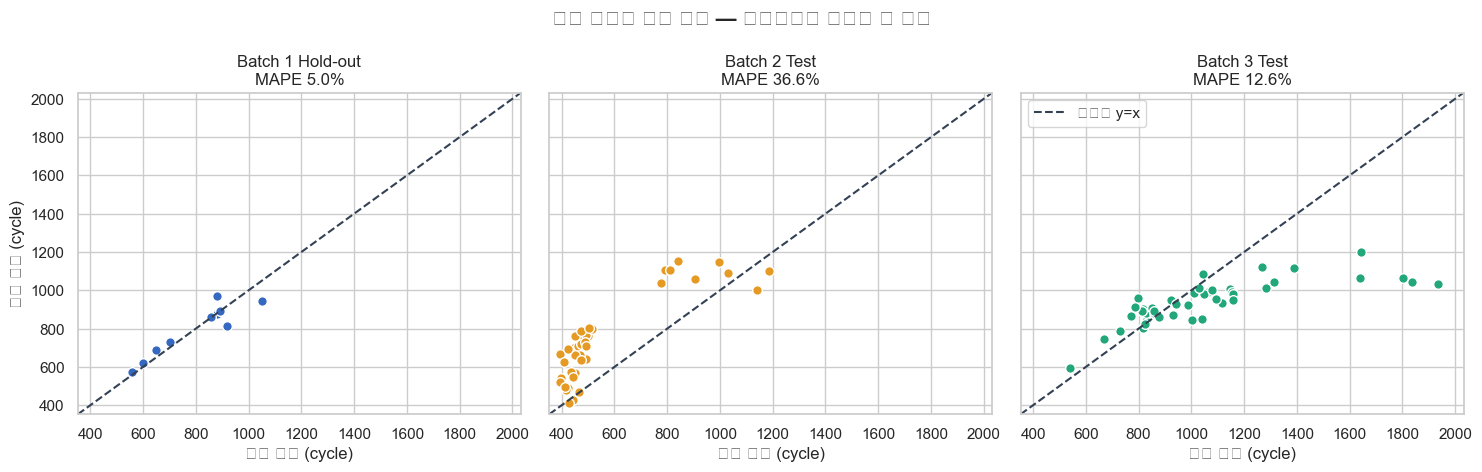

/var/folders/zb/jr1wvwf97ssf0lbcg9tv2fhr0000gn/T/ipykernel_17523/773560068.py:20: UserWarning: Glyph 51092 (\N{HANGUL SYLLABLE JAN}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/zb/jr1wvwf97ssf0lbcg9tv2fhr0000gn/T/ipykernel_17523/773560068.py:20: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/zb/jr1wvwf97ssf0lbcg9tv2fhr0000gn/T/ipykernel_17523/773560068.py:20: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/zb/jr1wvwf97ssf0lbcg9tv2fhr0000gn/T/ipykernel_17523/773560068.py:20: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/zb/jr1wvwf97ssf0lbcg9tv2fhr0000gn/T/ipykernel_17523/773560068.py:20: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/zb/jr1wvwf97ssf0lb

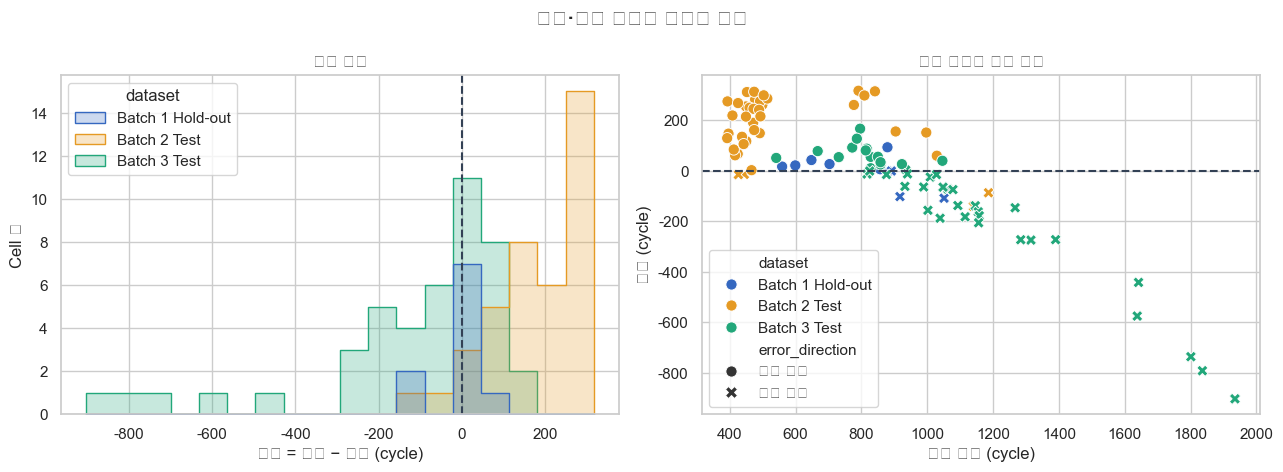

,dataset,n,실제_평균,예측_평균,평균_잔차,과대예측률
0,Batch 1 Hold-out,10,798.4000,797.6100,-0.7900,60.0000
1,Batch 2 Test,39,565.7400,741.4300,175.6900,89.7400
2,Batch 3 Test,44,"1,059.6600",941.6700,-117.9900,36.3600


In [15]:
colors = {"Batch 1 Hold-out": "#3568C0", "Batch 2 Test": "#E59A24", "Batch 3 Test": "#22A77A"}
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharex=True, sharey=True)
limits = [predictions[["cycle_life", "prediction"]].min().min() * .9,
          predictions[["cycle_life", "prediction"]].max().max() * 1.05]
for ax, dataset_name in zip(axes, colors):
    frame = predictions.query("dataset == @dataset_name")
    ax.scatter(frame["cycle_life"], frame["prediction"], s=48, color=colors[dataset_name], edgecolor="white")
    ax.plot(limits, limits, "--", color="#334155", label="정답선 y=x")
    ax.set(title=f"{dataset_name}\nMAPE {frame.ape_pct.mean():.1f}%", xlabel="실제 수명 (cycle)", xlim=limits, ylim=limits)
axes[0].set_ylabel("예측 수명 (cycle)"); axes[-1].legend()
fig.suptitle("실제 수명과 예측 수명 — 대각선에서 멀수록 큰 오차", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
sns.histplot(data=predictions, x="residual", hue="dataset", bins=18, element="step", common_norm=False, ax=axes[0], palette=colors)
axes[0].axvline(0, color="#334155", ls="--"); axes[0].set(title="잔차 분포", xlabel="잔차 = 예측 − 실제 (cycle)", ylabel="Cell 수")
sns.scatterplot(data=predictions, x="cycle_life", y="residual", hue="dataset", style="error_direction", s=65, ax=axes[1], palette=colors)
axes[1].axhline(0, color="#334155", ls="--"); axes[1].set(title="실제 수명에 따른 잔차", xlabel="실제 수명 (cycle)", ylabel="잔차 (cycle)")
fig.suptitle("과대·과소 예측의 방향과 크기", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.show()
display(predictions.groupby("dataset", as_index=False).agg(
    n=("global_cell_id", "size"), 실제_평균=("cycle_life", "mean"), 예측_평균=("prediction", "mean"),
    평균_잔차=("residual", "mean"), 과대예측률=("residual", lambda s: 100 * (s > 0).mean())
).round(2))

Batch 2는 평균 실제 565.7 cycle을 741.4 cycle로 예측했고 39개 중 35개를 과대 예측했다. Batch 전체 방향의 편향이므로 ESS에서는 정비 지연 위험이다.

## 10. 수명·충전조건별 오류, 최악 Cell, Feature shift

아래 함수는 방금 계산한 `predictions`와 세 Batch Feature에서 오류표를 직접 만든다.

In [16]:
def build_error_tables(evaluation: dict[str, Any], selected_features: list[str]) -> dict[str, pd.DataFrame]:
    predictions = evaluation["predictions"].copy()
    group_rows = []
    for (dataset, group), frame in predictions.groupby(["dataset", "life_group"], observed=True):
        metrics = regression_metrics(frame["cycle_life"], frame["prediction"])
        group_rows.append({"dataset": dataset, "life_group": group, "n": len(frame), **metrics})
    group_error = pd.DataFrame(group_rows)

    charging = predictions.copy()
    charging["c_rate_bin"] = pd.cut(
        charging["c_rate_stage1"],
        bins=[-np.inf, 4, 6, np.inf],
        labels=["저속(≤4C)", "중간(4~6C)", "고속(>6C)"],
    )
    charging_rows = []
    for (dataset, cbin), frame in charging.dropna(subset=["c_rate_bin"]).groupby(
        ["dataset", "c_rate_bin"], observed=True
    ):
        charging_rows.append(
            {
                "dataset": dataset,
                "c_rate_bin": str(cbin),
                "n": len(frame),
                "mape_pct": float(frame["ape_pct"].mean()),
                "mae": float(frame["absolute_error"].mean()),
                "overprediction_rate_pct": float(100 * (frame["residual"] > 0).mean()),
            }
        )
    charging_error = pd.DataFrame(charging_rows)
    worst = predictions[predictions["dataset"].isin(["Batch 2 Test", "Batch 3 Test"])].nlargest(10, "ape_pct")

    combined = pd.concat([evaluation["batch1_all"], evaluation["batch2"], evaluation["batch3"]], ignore_index=True)
    shift_rows = []
    batch1 = combined[combined["batch"] == "Batch 1"]
    for feature in selected_features:
        base = pd.to_numeric(batch1[feature], errors="coerce")
        base_mean, base_std = base.mean(), base.std(ddof=1)
        for batch, frame in combined.groupby("batch", sort=False):
            values = pd.to_numeric(frame[feature], errors="coerce")
            shift_rows.append(
                {
                    "feature": feature,
                    "batch": batch,
                    "n_available": int(values.notna().sum()),
                    "missing_pct": float(100 * values.isna().mean()),
                    "mean": float(values.mean()),
                    "median": float(values.median()),
                    "std": float(values.std(ddof=1)),
                    "standardized_mean_shift_vs_batch1": float((values.mean() - base_mean) / base_std) if base_std > 0 else np.nan,
                    "outside_batch1_range_pct": float(100 * ((values < base.min()) | (values > base.max())).mean()),
                }
            )
    batch_shift = pd.DataFrame(shift_rows)
    return {
        "life_group_error": group_error,
        "charging_error": charging_error,
        "worst_predictions": worst,
        "batch_shift": batch_shift,
    }

def extract_importance(model: Pipeline, features: list[str]) -> pd.DataFrame:
    imputer = model.named_steps["imputer"]
    names = list(imputer.get_feature_names_out(features))
    estimator = model.named_steps["model"]
    if hasattr(estimator, "coef_"):
        values = np.asarray(estimator.coef_).reshape(-1)
        kind = "표준화 계수"
    elif hasattr(estimator, "feature_importances_"):
        values = np.asarray(estimator.feature_importances_).reshape(-1)
        kind = "Feature importance"
    else:
        values = np.zeros(len(names))
        kind = "해당 없음"
    return pd.DataFrame(
        {"feature": names, "importance": values, "absolute_importance": np.abs(values), "importance_type": kind}
    ).sort_values("absolute_importance", ascending=False)

In [17]:
evaluation = {"predictions": predictions, "batch1_all": batch1_all, "batch2": batch2, "batch3": batch3}
error_tables = build_error_tables(evaluation, selected_features)
importance = extract_importance(final_model, selected_features)
life_error = error_tables["life_group_error"]
charging_error = error_tables["charging_error"]
worst = error_tables["worst_predictions"]
batch_shift = error_tables["batch_shift"]
display(life_error.round(2)); display(charging_error.round(2))
display(worst[["dataset", "global_cell_id", "cycle_life", "prediction", "ape_pct", "error_direction"]].round(2))

,dataset,life_group,n,mape_pct,mae,rmse,r2,median_ape_pct
0,Batch 1 Hold-out,"장수명(>1,000)",1,10.3200,108.4400,108.4400,NaN,10.3200
1,Batch 1 Hold-out,"중간수명(500~1,000)",9,4.4000,34.5400,49.8100,0.8600,3.5500
2,Batch 2 Test,단수명(<500),28,39.4800,178.5200,200.9900,-38.8300,41.9700
3,Batch 2 Test,"장수명(>1,000)",3,8.4800,95.6400,101.3900,-1.3700,7.3300
4,Batch 2 Test,"중간수명(500~1,000)",8,36.8800,259.9800,267.6700,-1.6900,37.0900
5,Batch 3 Test,"장수명(>1,000)",23,18.0500,262.9800,361.0900,-0.6000,15.5900
6,Batch 3 Test,"중간수명(500~1,000)",21,6.6900,52.9900,67.2700,0.5200,6.5200


,dataset,c_rate_bin,n,mape_pct,mae,overprediction_rate_pct
0,Batch 1 Hold-out,중간(4~6C),6,4.2900,36.7900,50.0000
1,Batch 1 Hold-out,고속(>6C),4,6.0400,49.6300,75.0000
2,Batch 2 Test,저속(≤4C),4,31.2900,124.3900,75.0000
3,Batch 2 Test,중간(4~6C),35,37.1600,196.2200,91.4300
4,Batch 3 Test,저속(≤4C),3,10.9800,73.4600,100.0000
5,Batch 3 Test,중간(4~6C),41,12.7500,169.2900,31.7100


,dataset,global_cell_id,cycle_life,prediction,ape_pct,error_direction
16,Batch 2 Test,Batch2_006,393.0000,667.3800,69.8200,과대 예측
37,Batch 2 Test,Batch2_029,452.0000,763.2900,68.8700,과대 예측
44,Batch 2 Test,Batch2_042,474.0000,786.5000,65.9300,과대 예측
39,Batch 2 Test,Batch2_031,425.0000,692.7500,63.0000,과대 예측
48,Batch 2 Test,Batch2_046,503.0000,801.4400,59.3300,과대 예측
10,Batch 2 Test,Batch2_000,477.0000,759.4400,59.2100,과대 예측
21,Batch 2 Test,Batch2_011,449.0000,703.3200,56.6400,과대 예측
20,Batch 2 Test,Batch2_010,492.0000,767.2300,55.9400,과대 예측
32,Batch 2 Test,Batch2_024,514.0000,799.7900,55.6000,과대 예측
23,Batch 2 Test,Batch2_013,460.0000,709.3400,54.2000,과대 예측


/var/folders/zb/jr1wvwf97ssf0lbcg9tv2fhr0000gn/T/ipykernel_17523/1054325517.py:8: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/zb/jr1wvwf97ssf0lbcg9tv2fhr0000gn/T/ipykernel_17523/1054325517.py:8: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/zb/jr1wvwf97ssf0lbcg9tv2fhr0000gn/T/ipykernel_17523/1054325517.py:8: UserWarning: Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/zb/jr1wvwf97ssf0lbcg9tv2fhr0000gn/T/ipykernel_17523/1054325517.py:8: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/zb/jr1wvwf97ssf0lbcg9tv2fhr0000gn/T/ipykernel_17523/1054325517.py:8: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/zb/jr1wvwf97ss

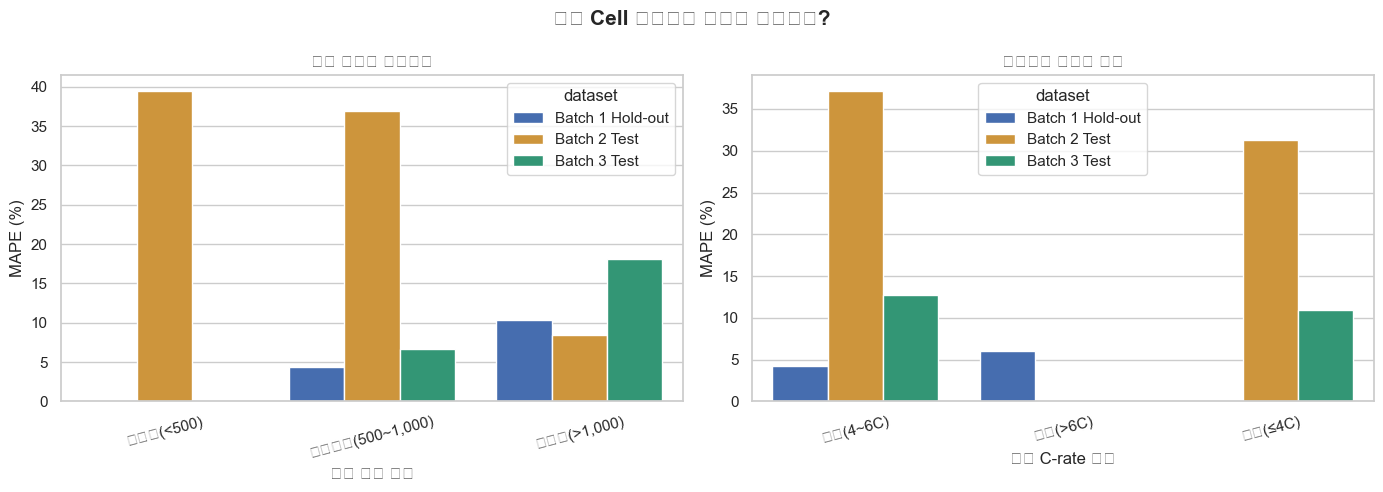

In [18]:
life_order = ["단수명(<500)", "중간수명(500~1,000)", "장수명(>1,000)"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=life_error, x="life_group", y="mape_pct", hue="dataset", order=life_order, palette=colors, ax=axes[0])
axes[0].set(title="수명 구간별 상대오차", xlabel="실제 수명 구간", ylabel="MAPE (%)"); axes[0].tick_params(axis="x", rotation=15)
sns.barplot(data=charging_error, x="c_rate_bin", y="mape_pct", hue="dataset", palette=colors, ax=axes[1])
axes[1].set(title="충전속도 구간별 오차", xlabel="초기 C-rate 구간", ylabel="MAPE (%)"); axes[1].tick_params(axis="x", rotation=15)
fig.suptitle("어떤 Cell 집단에서 모델이 취약한가?", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.show()

/var/folders/zb/jr1wvwf97ssf0lbcg9tv2fhr0000gn/T/ipykernel_17523/1613859680.py:10: UserWarning: Glyph 51208 (\N{HANGUL SYLLABLE JEOL}) missing from font(s) Arial.
  plt.tight_layout(); plt.show(); display(importance.round(3))
/var/folders/zb/jr1wvwf97ssf0lbcg9tv2fhr0000gn/T/ipykernel_17523/1613859680.py:10: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) Arial.
  plt.tight_layout(); plt.show(); display(importance.round(3))
/var/folders/zb/jr1wvwf97ssf0lbcg9tv2fhr0000gn/T/ipykernel_17523/1613859680.py:10: UserWarning: Glyph 48177 (\N{HANGUL SYLLABLE BAEG}) missing from font(s) Arial.
  plt.tight_layout(); plt.show(); display(importance.round(3))
/var/folders/zb/jr1wvwf97ssf0lbcg9tv2fhr0000gn/T/ipykernel_17523/1613859680.py:10: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) Arial.
  plt.tight_layout(); plt.show(); display(importance.round(3))
/var/folders/zb/jr1wvwf97ssf0lbcg9tv2fhr0000gn/T/ipykernel_17523/1613859680.py:10: UserWarning: Gl

/opt/homebrew/Cellar/jupyterlab/4.2.5_1/libexec/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Cellar/jupyterlab/4.2.5_1/libexec/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Cellar/jupyterlab/4.2.5_1/libexec/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Cellar/jupyterlab/4.2.5_1/libexec/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50752 (\N{HANGUL SYLLABLE WA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Cellar/jupyterlab/4.2.5_1/libexec/lib/python3.12/site-packages/IPyth

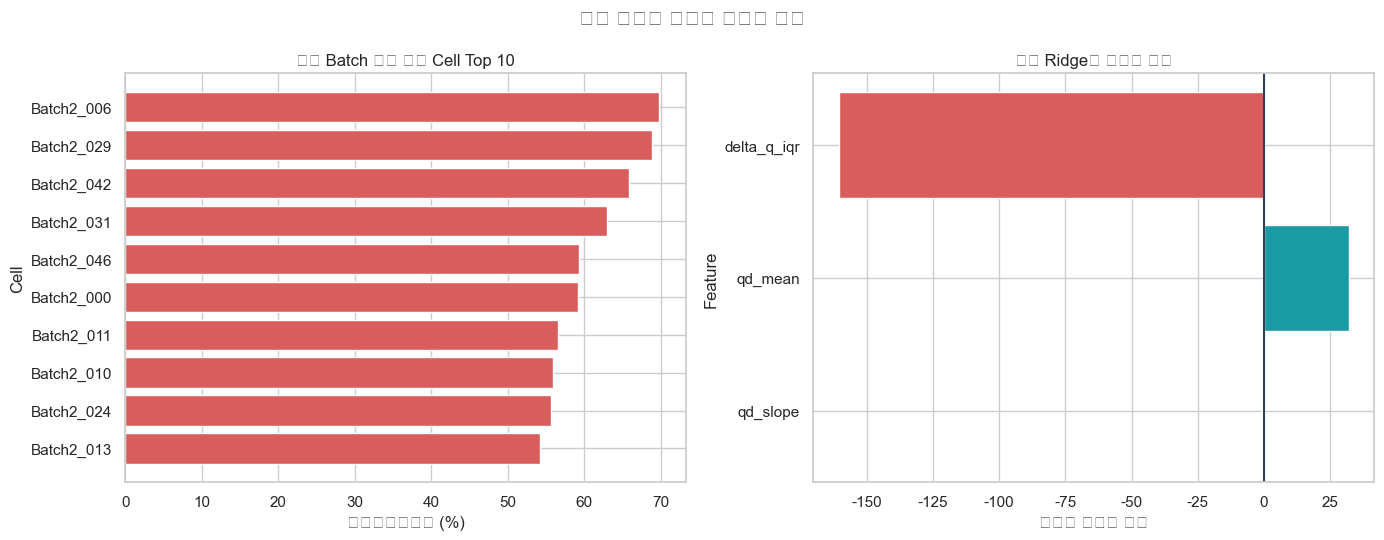

,feature,importance,absolute_importance,importance_type
0,delta_q_iqr,-160.6670,160.6670,표준화 계수
1,qd_mean,32.0290,32.0290,표준화 계수
2,qd_slope,-0.5300,0.5300,표준화 계수


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
worst_plot = worst.sort_values("ape_pct")
axes[0].barh(worst_plot["global_cell_id"], worst_plot["ape_pct"], color="#D95D5D")
axes[0].set(title="외부 Batch 최악 예측 Cell Top 10", xlabel="절대백분율오차 (%)", ylabel="Cell")
imp = importance.sort_values("absolute_importance")
imp_colors = ["#D95D5D" if value < 0 else "#1A9AA3" for value in imp["importance"]]
axes[1].barh(imp["feature"], imp["importance"], color=imp_colors); axes[1].axvline(0, color="#334155")
axes[1].set(title="최종 Ridge의 표준화 계수", xlabel="계수의 크기와 방향", ylabel="Feature")
fig.suptitle("실패 사례와 모델이 사용한 신호", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.show(); display(importance.round(3))

/opt/homebrew/Cellar/jupyterlab/4.2.5_1/libexec/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) Arial.
  fig.canvas.draw()
/opt/homebrew/Cellar/jupyterlab/4.2.5_1/libexec/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) Arial.
  fig.canvas.draw()
/opt/homebrew/Cellar/jupyterlab/4.2.5_1/libexec/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 54200 (\N{HANGUL SYLLABLE PYEON}) missing from font(s) Arial.
  fig.canvas.draw()
/opt/homebrew/Cellar/jupyterlab/4.2.5_1/libexec/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) Arial.
  fig.canvas.draw()
/opt/homebrew/Cellar/jupyterlab/4.2.5_1/libexec/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) Arial.
  fig.canvas.draw()
/opt/homebrew/

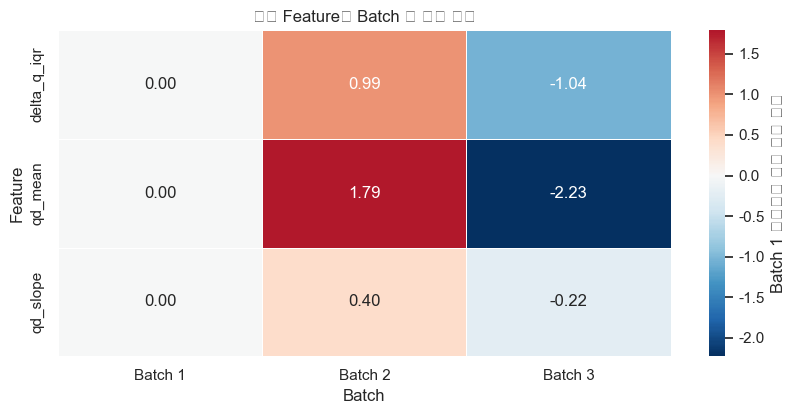

,feature,batch,n_available,missing_pct,mean,median,std,standardized_mean_shift_vs_batch1,outside_batch1_range_pct
0,delta_q_iqr,Batch 1,46,0.0000,0.0200,0.0190,0.0070,0.0000,0.0000
1,delta_q_iqr,Batch 2,39,0.0000,0.0270,0.0290,0.0100,0.9910,30.7690
2,delta_q_iqr,Batch 3,44,0.0000,0.0130,0.0130,0.0040,-1.0400,6.8180
3,qd_mean,Batch 1,46,0.0000,1.0820,1.0820,0.0070,0.0000,0.0000
4,qd_mean,Batch 2,39,0.0000,1.0950,1.0980,0.0110,1.7880,51.2820
5,qd_mean,Batch 3,44,0.0000,1.0650,1.0680,0.0080,-2.2260,20.4550
6,qd_slope,Batch 1,46,0.0000,-0.0000,-0.0000,0.0000,0.0000,0.0000
7,qd_slope,Batch 2,39,0.0000,0.0000,0.0000,0.0000,0.4020,43.5900
8,qd_slope,Batch 3,44,0.0000,-0.0000,-0.0000,0.0000,-0.2220,0.0000


In [20]:
shift_pivot = batch_shift.pivot(index="feature", columns="batch", values="standardized_mean_shift_vs_batch1").reindex(columns=["Batch 1", "Batch 2", "Batch 3"])
fig, ax = plt.subplots(figsize=(8.5, 4.3))
sns.heatmap(shift_pivot, cmap="RdBu_r", center=0, annot=True, fmt=".2f", linewidths=.5,
            cbar_kws={"label": "Batch 1 표준편차 단위 평균 이동"}, ax=ax)
ax.set(title="최종 Feature의 Batch 간 분포 이동", xlabel="Batch", ylabel="Feature")
plt.tight_layout(); plt.show(); display(batch_shift.round(3))

Batch 2는 `delta_q_iqr`가 +0.99 SD, `qd_mean`이 +1.79 SD 이동했고 `qd_mean`의 51.3%가 Batch 1 범위 밖이다. Batch 3은 반대 방향이다. 외부 성능 차이는 학습 분포 밖 외삽과 Feature–수명 관계 변화로 해석한다.

## 11. ESS 운영 해석과 한계

- **과대 예측:** 점검·교체 지연과 안전 여유 감소. Batch 2에서 집중된 위험이다.
- **과소 예측:** 조기 교체와 예비품·인력 과투입.
- 현재 모델은 drift 경고, 조건별 재검증, 안전 마진 없이 운영에 직접 배포할 수 없다.
- Batch 1 labeled Cell은 46개로 작고 실험실 데이터가 실제 ESS의 온도 구배·불균형·가변 부하를 모두 대표하지 않는다.
- 충전정책은 Batch·실험시기·Cell 구조와 함께 변하므로 C-rate의 인과효과로 단정할 수 없다.

## 12. 제출 전 자동검사

In [21]:
checks = {
    "입력 Feature에 미래정보 없음": not any(token in name.lower() for name in selected_features for token in FORBIDDEN_FEATURE_PATTERNS),
    "최종 Feature 3개": set(selected_features) == {"delta_q_iqr", "qd_mean", "qd_slope"},
    "최종 모델 Ridge": selected_model_name == "Ridge",
    "alpha 1.0": selected_params == {"model__alpha": 1.0},
    "필수 평가 4구간": set(performance["dataset"]) == {"Train (Batch 1 CV)", "Batch 1 Hold-out", "Batch 2 Test", "Batch 3 Test"},
    "필수 Gap 4개": set(gaps["gap"]) == {"Train-Valid", "Valid-Test", "Target-Test", "Batch2-Batch3"},
    "외부 선택 미사용": lock["batch2_used_for_selection"] is False,
    "외부 결과 후 재튜닝 없음": lock["post_batch2_retuning"] is False,
    "예측 결측 없음": predictions["prediction"].notna().all(),
}
display(pd.DataFrame([{"검사": name, "결과": "통과" if passed else "실패"} for name, passed in checks.items()]))
assert all(checks.values())
print("모든 제출 핵심검사 통과")

,검사,결과
0,입력 Feature에 미래정보 없음,통과
1,최종 Feature 3개,통과
2,최종 모델 Ridge,통과
3,alpha 1.0,통과
4,필수 평가 4구간,통과
5,필수 Gap 4개,통과
6,외부 선택 미사용,통과
7,외부 결과 후 재튜닝 없음,통과
8,예측 결측 없음,통과


모든 제출 핵심검사 통과


## 13. 최종 결론

1. ΔQ screening과 F0~F4 Ablation 결과 `delta_q_iqr`, `qd_mean`, `qd_slope`를 선택했다.
2. 다섯 모델을 같은 반복 CV로 비교하고 1-SE 규칙으로 **Ridge(alpha=1.0)**를 선택했다.
3. Batch 1 CV 7.68%, hold-out 4.99%, Batch 2 36.56%, Batch 3 12.63%였다.
4. Batch 2의 단수명 Cell 대부분을 과대 예측했으므로 안전 관점에서 직접 배포할 수 없다.
5. 가장 중요한 결론은 내부 CV뿐 아니라 **Batch drift와 과대 예측 방향을 운영 중 감시해야 한다**는 것이다.

부족한 Feature나 모델을 추가할 때도 `feature_sets`, `model_specs`, 오류 분석 셀을 직접 수정해 확장할 수 있다.